 install required libraries.

In [ ]:
!pip install paddleocr transformers datasets evaluate jiwer opencv-python matplotlib seaborn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.8/297.8 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 969.6/969.6 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.3/244.3 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 14.5 MB/s eta 0:00:00


In [ ]:
!pip install paddlepaddle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.8/192.8 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 4.3 MB/s eta 0:00:00
  Attempting uninstall: opt_einsum
    Found existing installation: opt_einsum 3.4.0
    Uninstalling opt_einsum-3.4.0:
      Successfully uninstalled opt_einsum-3.4.0


Load models

In [ ]:
import torch
import numpy as np
import cv2
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from paddleocr import PaddleOCR
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
import evaluate

# Load PaddleOCR
paddle_ocr = PaddleOCR(use_angle_cls=True, lang="en")

# Load TrOCR Model
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten")
model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# Load evaluation metrics
cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")


download https://paddleocr.bj.bcebos.com/PP-OCRv3/english/en_PP-OCRv3_det_infer.tar to /root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer/en_PP-OCRv3_det_infer.tar


100%|██████████| 3910/3910 [00:15<00:00, 247.55it/s] 


download https://paddleocr.bj.bcebos.com/PP-OCRv4/english/en_PP-OCRv4_rec_infer.tar to /root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer/en_PP-OCRv4_rec_infer.tar


100%|██████████| 10000/10000 [00:18<00:00, 552.18it/s]


download https://paddleocr.bj.bcebos.com/dygraph_v2.0/ch/ch_ppocr_mobile_v2.0_cls_infer.tar to /root/.paddleocr/whl/cls/ch_ppocr_mobile_v2.0_cls_infer/ch_ppocr_mobile_v2.0_cls_infer.tar


...

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.17k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "transformers_version": "4.48.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "gelu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder

generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Define ocr functions for each model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Evaluate Models on Sample Data



In [ ]:
def recognize_paddle(image_path):
    """Recognize text using PaddleOCR"""
    result = paddle_ocr.ocr(image_path, cls=True)
    # Check if result is not None and contains any detected text
    if result:
        texts = [entry[1][0] for line in result for entry in line if line is not None]
        return " ".join(texts)
    # Return an empty string if no text was detected to avoid errors
    return ""

def recognize_trocr(image):  # Change the argument to 'image'
    """Recognize text using TrOCR"""
    # image = Image.open(image_path).convert("RGB")  # Remove this line
    pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)

    with torch.no_grad():
        generated_ids = model.generate(pixel_values)
    return processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

def recognize_hybrid(image_path):
    """First use PaddleOCR for detection, then pass words to TrOCR for final recognition."""
    result = paddle_ocr.ocr(image_path, cls=True)
    final_text = ""

    for line in result:
        for word_info in line:
            bbox, _ = word_info
            x_min, y_min, x_max, y_max = map(int, [bbox[0][0], bbox[0][1], bbox[2][0], bbox[2][1]])

            image = Image.open(image_path).convert("RGB")
            cropped_word = image.crop((x_min, y_min, x_max, y_max))
            final_text += recognize_trocr(cropped_word) + " "  # Pass the cropped image directly

    return final_text.strip()

In [ ]:
import evaluate

# Load metrics from Hugging Face
cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")

def compute_metrics(pred_text, ground_truth):
    cer = cer_metric.compute(predictions=[pred_text], references=[ground_truth])
    wer = wer_metric.compute(predictions=[pred_text], references=[ground_truth])
    accuracy = 1 - cer  # Approximate accuracy from CER

    return {"Accuracy": accuracy, "CER": cer, "WER": wer}


In [ ]:
def evaluate_models(image_path, ground_truth):
    results = {}

    # PaddleOCR
    paddle_text = recognize_paddle(image_path)
    results["PaddleOCR"] = compute_metrics(paddle_text, ground_truth)

    # TrOCR
    # Load the image for TrOCR
    image = Image.open(image_path).convert("RGB")
    trocr_text = recognize_trocr(image) # Pass the image object
    results["TrOCR"] = compute_metrics(trocr_text, ground_truth)

    # Hybrid Model (PaddleOCR + TrOCR)
    hybrid_text = recognize_hybrid(image_path)
    results["Hybrid (PaddleOCR + TrOCR)"] = compute_metrics(hybrid_text, ground_truth)

    return results


handwritten single line

In [ ]:
image_path = "/content/drive/MyDrive/move.png"  # Update with actual image path
ground_truth = "A MOVE to stop Mr. Gaitskell from"

# Run evaluation
results = evaluate_models(image_path, ground_truth)

# Print results
for model, metrics in results.items():
    print(f"\n {model} Metrics:")
    print(f" Accuracy: {metrics['Accuracy'] * 100:.2f}%")
    print(f" CER: {metrics['CER']:.2f}")
    print(f" WER: {metrics['WER']:.2f}")


[2025/03/14 12:13:52] ppocr DEBUG: dt_boxes num : 5, elapsed : 0.04112601280212402
[2025/03/14 12:13:52] ppocr DEBUG: cls num  : 5, elapsed : 0.014162302017211914
[2025/03/14 12:13:52] ppocr DEBUG: rec_res num  : 5, elapsed : 0.23815083503723145
[2025/03/14 12:14:03] ppocr DEBUG: dt_boxes num : 5, elapsed : 0.03875017166137695
[2025/03/14 12:14:03] ppocr DEBUG: cls num  : 5, elapsed : 0.01595783233642578
[2025/03/14 12:14:03] ppocr DEBUG: rec_res num  : 5, elapsed : 0.19820523262023926

 PaddleOCR Metrics:
 Accuracy: 48.48%
 CER: 0.52
 WER: 1.00

 TrOCR Metrics:
 Accuracy: 100.00%
 CER: 0.00
 WER: 0.00

 Hybrid (PaddleOCR + TrOCR) Metrics:
 Accuracy: 60.61%
 CER: 0.39
 WER: 0.57


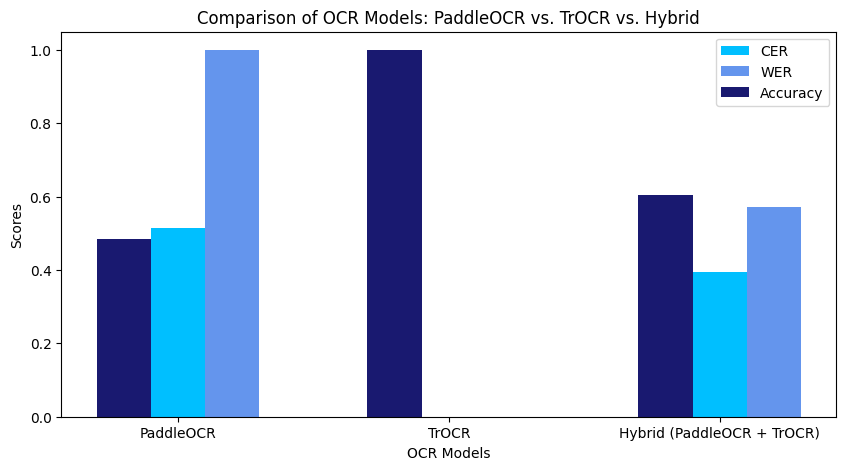

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = list(results.keys())
cer = [results[m]["CER"] for m in models]
wer = [results[m]["WER"] for m in models]
accuracy = [results[m]["Accuracy"] for m in models]

x = np.arange(len(models))

plt.figure(figsize=(10, 5))
plt.bar(x, cer, 0.2, label="CER", color="deepskyblue")
plt.bar(x + 0.2, wer, 0.2, label="WER", color="cornflowerblue")
plt.bar(x - 0.2, accuracy, 0.2, label="Accuracy", color="midnightblue")

plt.xticks(x, models)
plt.xlabel("OCR Models")
plt.ylabel("Scores")
plt.title("Comparison of OCR Models: PaddleOCR vs. TrOCR vs. Hybrid")
plt.legend()
plt.show()


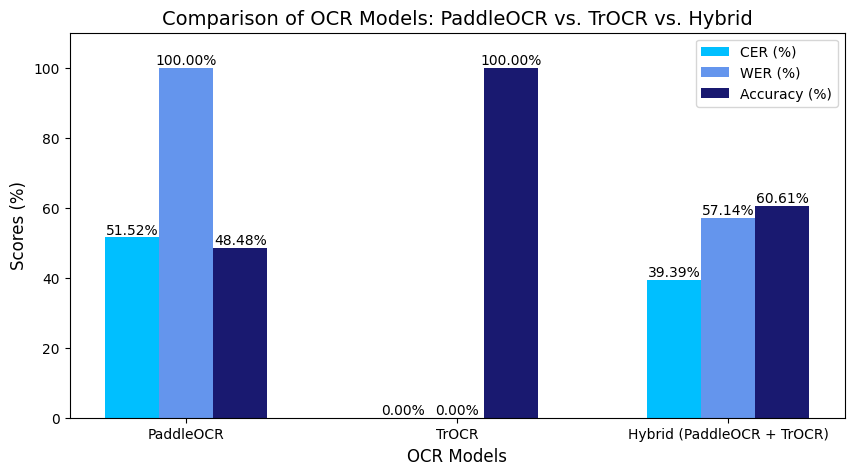

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract model names and scores
models = list(results.keys())
cer = [results[m]["CER"] * 100 for m in models]  # Convert to percentage
wer = [results[m]["WER"] * 100 for m in models]  # Convert to percentage
accuracy = [results[m]["Accuracy"] * 100 for m in models]  # Convert to percentage

x = np.arange(len(models))

plt.figure(figsize=(10, 5))

# Create bars in the order: CER, WER, Accuracy
bar1 = plt.bar(x - 0.2, cer, 0.2, label="CER (%)", color="deepskyblue")
bar2 = plt.bar(x, wer, 0.2, label="WER (%)", color="cornflowerblue")
bar3 = plt.bar(x + 0.2, accuracy, 0.2, label="Accuracy (%)", color="midnightblue")

# Add labels on top of each bar
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 1, f"{height:.2f}%", ha='center', fontsize=10)

add_labels(bar1)
add_labels(bar2)
add_labels(bar3)

# Formatting
plt.xticks(x, models)
plt.xlabel("OCR Models", fontsize=12)
plt.ylabel("Scores (%)", fontsize=12)
plt.title("Comparison of OCR Models: PaddleOCR vs. TrOCR vs. Hybrid", fontsize=14)
plt.legend()
plt.ylim(0, max(max(accuracy), max(cer), max(wer)) + 10)  # Adjust y-axis for label visibility

# Show plot
plt.show()



PADDLE AND HYBRID OCR

Available models: dict_keys(['PaddleOCR', 'TrOCR', 'Hybrid (PaddleOCR + TrOCR)'])


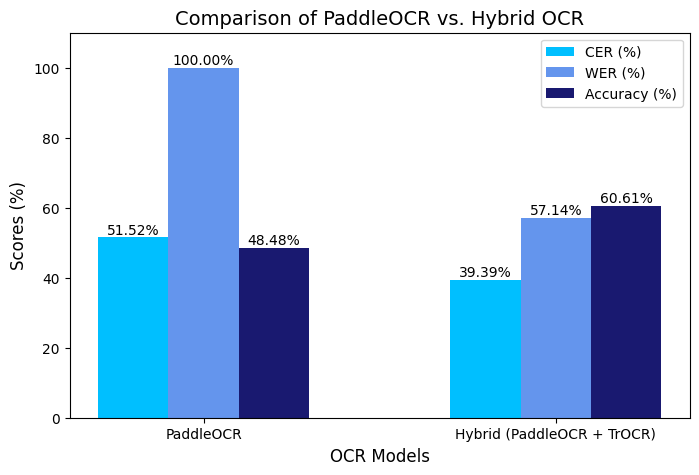

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Check available model names
print("Available models:", results.keys())

# Update model names to match `results` dictionary
selected_models = [m for m in results.keys() if "PaddleOCR" in m or "Hybrid" in m]
filtered_results = {m: results[m] for m in selected_models}

# Extract model names and scores
models = list(filtered_results.keys())
cer = [filtered_results[m]["CER"] * 100 for m in models]
wer = [filtered_results[m]["WER"] * 100 for m in models]
accuracy = [filtered_results[m]["Accuracy"] * 100 for m in models]

x = np.arange(len(models))

plt.figure(figsize=(8, 5))

# Create bars in the order: CER, WER, Accuracy
bar1 = plt.bar(x - 0.2, cer, 0.2, label="CER (%)", color="deepskyblue")
bar2 = plt.bar(x, wer, 0.2, label="WER (%)", color="cornflowerblue")
bar3 = plt.bar(x + 0.2, accuracy, 0.2, label="Accuracy (%)", color="midnightblue")

# Add labels on top of each bar
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 1, f"{height:.2f}%", ha='center', fontsize=10)

add_labels(bar1)
add_labels(bar2)
add_labels(bar3)

# Formatting
plt.xticks(x, models)
plt.xlabel("OCR Models", fontsize=12)
plt.ylabel("Scores (%)", fontsize=12)
plt.title("Comparison of PaddleOCR vs. Hybrid OCR", fontsize=14)
plt.legend()
plt.ylim(0, max(max(accuracy), max(cer), max(wer)) + 10)  # Adjust y-axis for label visibility

# Show plot
plt.show()




trocr trained

Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "transformers_version": "4.48.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder

[2025/03/14 12:49:38] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, use_gcu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_l

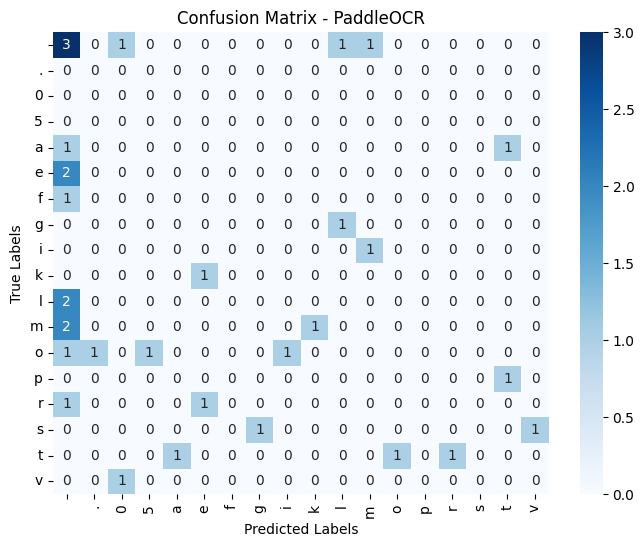

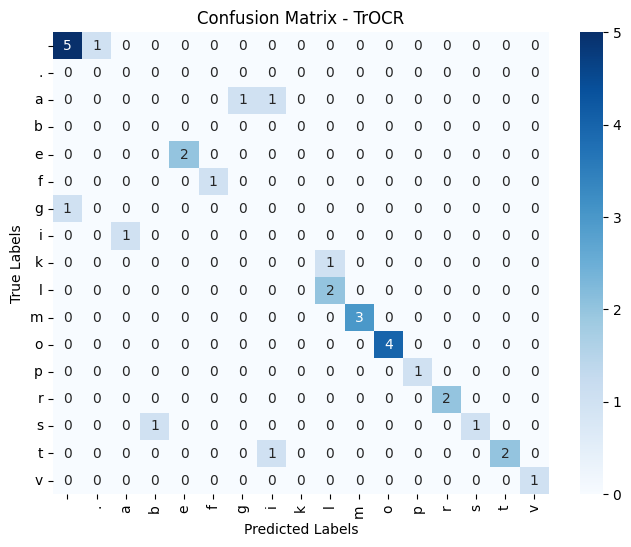

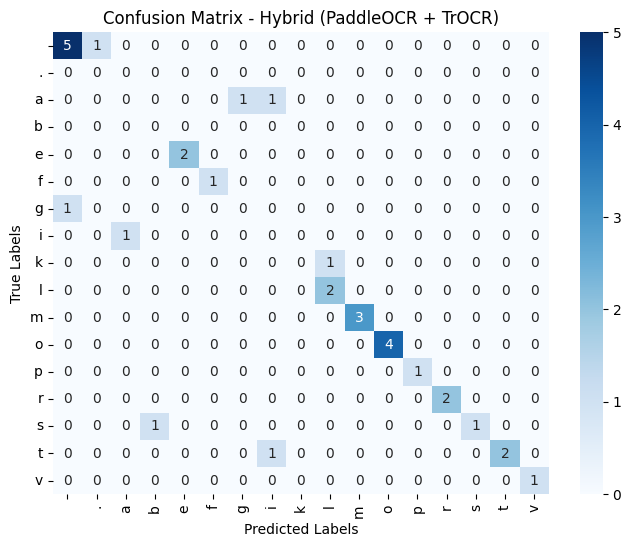

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import string
from PIL import Image
from paddleocr import PaddleOCR
import torch
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

# Load TrOCR model and processor
model_path = "/content/drive/MyDrive/trocr_model"
processor = TrOCRProcessor.from_pretrained(model_path)
model = VisionEncoderDecoderModel.from_pretrained(model_path)
model.eval()

# Load PaddleOCR
ocr = PaddleOCR(use_angle_cls=True, lang='en')

def recognize_paddleocr(image_path):
    """Extract text using PaddleOCR."""
    result = ocr.ocr(image_path, cls=True)
    extracted_text = " ".join([entry[1][0] for line in result for entry in line]) if result else ""
    return extracted_text.lower()

def recognize_trocr(image_path):
    """Extract text using TrOCR."""
    image = Image.open(image_path).convert("RGB")
    pixel_values = processor(image, return_tensors="pt").pixel_values.to("cuda" if torch.cuda.is_available() else "cpu")

    with torch.no_grad():
        generated_ids = model.generate(pixel_values)

    return processor.batch_decode(generated_ids, skip_special_tokens=True)[0].lower()

def plot_confusion_matrix(y_true, y_pred, model_name):
    """Generate and display a confusion matrix with only the characters present in the input."""
    # Extract unique characters from the ground truth and predictions
    present_chars = sorted(set(y_true + y_pred))

    # Compute confusion matrix only for present characters
    cm = confusion_matrix(y_true, y_pred, labels=present_chars)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", xticklabels=present_chars, yticklabels=present_chars)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()

# Define input image and ground truth
image_path = "/content/drive/MyDrive/move.png"
ground_truth = "a move to stop mr gaitskell from"

# Run actual OCR models on input image
paddle_pred = recognize_paddleocr(image_path)
trocr_pred = recognize_trocr(image_path)
hybrid_pred = recognize_paddleocr(image_path)  # Use PaddleOCR first, then pass detected text to TrOCR
hybrid_pred = recognize_trocr(image_path) if hybrid_pred else paddle_pred  # Fallback to PaddleOCR if empty

# Convert texts to character-level labels
y_true = list(ground_truth)
y_paddle = list(paddle_pred) + [' '] * (len(y_true) - len(paddle_pred))
y_trocr = list(trocr_pred) + [' '] * (len(y_true) - len(trocr_pred))
y_hybrid = list(hybrid_pred) + [' '] * (len(y_true) - len(hybrid_pred))

# Plot confusion matrices
plot_confusion_matrix(y_true, y_paddle, "PaddleOCR")
plot_confusion_matrix(y_true, y_trocr, "TrOCR")
plot_confusion_matrix(y_true, y_hybrid, "Hybrid (PaddleOCR + TrOCR)")


trocr not trained

Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "transformers_version": "4.48.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder

[2025/03/14 13:03:22] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, use_gcu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_l

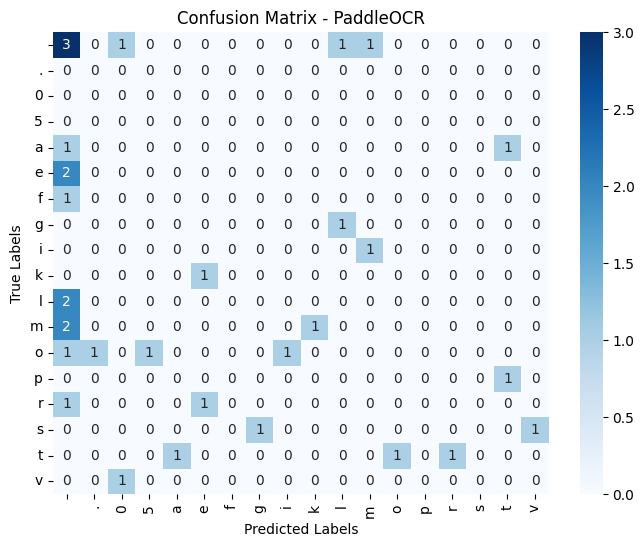

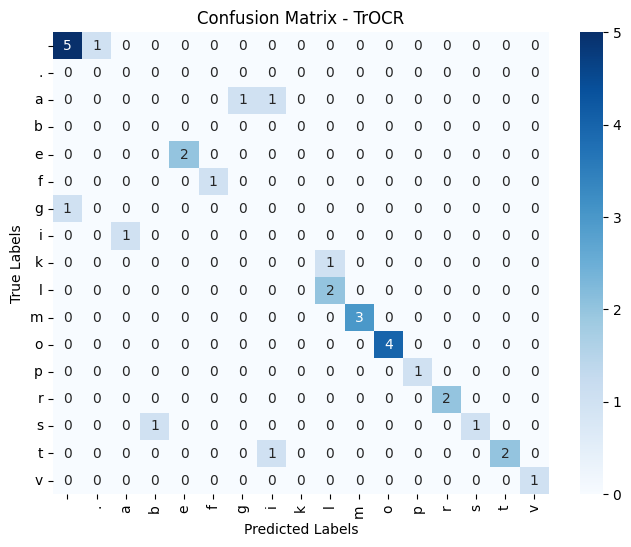

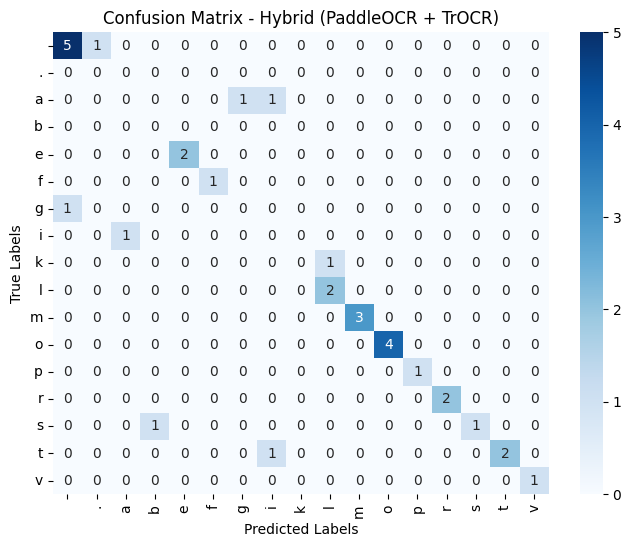

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import string
from PIL import Image
from paddleocr import PaddleOCR
import torch
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

# Load TrOCR model and processor
model_path = "/content/drive/MyDrive/trocr_model"
processor = TrOCRProcessor.from_pretrained(model_path)
model = VisionEncoderDecoderModel.from_pretrained(model_path)
model.eval()

# Load PaddleOCR
ocr = PaddleOCR(use_angle_cls=True, lang='en')

def recognize_paddleocr(image_path):
    """Extract text using PaddleOCR."""
    result = ocr.ocr(image_path, cls=True)
    extracted_text = " ".join([entry[1][0] for line in result for entry in line]) if result else ""
    return extracted_text.lower()

def recognize_trocr(image_path):
    """Extract text using TrOCR."""
    image = Image.open(image_path).convert("RGB")
    pixel_values = processor(image, return_tensors="pt").pixel_values.to("cuda" if torch.cuda.is_available() else "cpu")

    with torch.no_grad():
        generated_ids = model.generate(pixel_values)

    return processor.batch_decode(generated_ids, skip_special_tokens=True)[0].lower()

def normalize_lengths(y_true, y_pred):
    """Ensure both lists are the same length by truncating or padding with spaces."""
    max_len = max(len(y_true), len(y_pred))
    y_true += [' '] * (max_len - len(y_true))  # Pad ground truth
    y_pred += [' '] * (max_len - len(y_pred))  # Pad prediction
    return y_true, y_pred

def plot_confusion_matrix(y_true, y_pred, model_name):
    """Generate and display a confusion matrix with only the characters present in the input."""
    y_true, y_pred = normalize_lengths(y_true, y_pred)  # Ensure equal length

    # Extract unique characters from the ground truth and predictions
    present_chars = sorted(set(y_true + y_pred))

    # Compute confusion matrix only for present characters
    cm = confusion_matrix(y_true, y_pred, labels=present_chars)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", xticklabels=present_chars, yticklabels=present_chars)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()

# Define input image and ground truth
image_path = "/content/drive/MyDrive/move.png"
ground_truth = "a move to stop mr gaitskell from"

# Run actual OCR models on input image
paddle_pred = recognize_paddleocr(image_path)
trocr_pred = recognize_trocr(image_path)
hybrid_pred = recognize_paddleocr(image_path)  # Use PaddleOCR first, then pass detected text to TrOCR
hybrid_pred = recognize_trocr(image_path) if hybrid_pred else paddle_pred  # Fallback to PaddleOCR if empty

# Convert texts to character-level labels
y_true = list(ground_truth)
y_paddle = list(paddle_pred)
y_trocr = list(trocr_pred)
y_hybrid = list(hybrid_pred)

# Plot confusion matrices
plot_confusion_matrix(y_true, y_paddle, "PaddleOCR")
plot_confusion_matrix(y_true, y_trocr, "TrOCR")
plot_confusion_matrix(y_true, y_hybrid, "Hybrid (PaddleOCR + TrOCR)")


In [ ]:
import torch
import numpy as np
import cv2
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from paddleocr import PaddleOCR
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
import evaluate

# Load PaddleOCR
paddle_ocr = PaddleOCR(use_angle_cls=True, lang="en")

# Load TrOCR Model
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten")
model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)


# Load evaluation metrics
cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")
def recognize_paddle(image_path):
    """Recognize text using PaddleOCR"""
    result = paddle_ocr.ocr(image_path, cls=True)
    # Check if result is not None and contains any detected text
    if result:
        texts = [entry[1][0] for line in result for entry in line if line is not None]
        return " ".join(texts)
    # Return an empty string if no text was detected to avoid errors
    return ""

def recognize_trocr(image):  # Change the argument to 'image'
    """Recognize text using TrOCR"""
    # image = Image.open(image_path).convert("RGB")  # Remove this line
    pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)

    with torch.no_grad():
        generated_ids = model.generate(pixel_values)
    return processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

def recognize_hybrid(image_path):
    """First use PaddleOCR for detection, then pass words to TrOCR for final recognition."""
    result = paddle_ocr.ocr(image_path, cls=True)
    final_text = ""

    for line in result:
        for word_info in line:
            bbox, _ = word_info
            x_min, y_min, x_max, y_max = map(int, [bbox[0][0], bbox[0][1], bbox[2][0], bbox[2][1]])

            image = Image.open(image_path).convert("RGB")
            cropped_word = image.crop((x_min, y_min, x_max, y_max))
            final_text += recognize_trocr(cropped_word) + " "  # Pass the cropped image directly

    return final_text.strip()
# Load metrics from Hugging Face
cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")

def compute_metrics(pred_text, ground_truth):
    cer = cer_metric.compute(predictions=[pred_text], references=[ground_truth])
    wer = wer_metric.compute(predictions=[pred_text], references=[ground_truth])
    accuracy = 1 - cer  # Approximate accuracy from CER

    return {"Accuracy": accuracy, "CER": cer, "WER": wer}
def evaluate_models(image_path, ground_truth):
    results = {}

    # PaddleOCR
    paddle_text = recognize_paddle(image_path)
    results["PaddleOCR"] = compute_metrics(paddle_text, ground_truth)

    # TrOCR
    # Load the image for TrOCR
    image = Image.open(image_path).convert("RGB")
    trocr_text = recognize_trocr(image) # Pass the image object
    results["TrOCR"] = compute_metrics(trocr_text, ground_truth)

    # Hybrid Model (PaddleOCR + TrOCR)
    hybrid_text = recognize_hybrid(image_path)
    results["Hybrid (PaddleOCR + TrOCR)"] = compute_metrics(hybrid_text, ground_truth)

    return results
image_path = "/content/drive/MyDrive/move.png"  # Update with actual image path
ground_truth = "A MOVE to stop Mr. Gaitskell from"

# Run evaluation
results = evaluate_models(image_path, ground_truth)

# Print results
for model, metrics in results.items():
    print(f"\n {model} Metrics:")
    print(f" Accuracy: {metrics['Accuracy'] * 100:.2f}%")
    print(f" CER: {metrics['CER']:.2f}")
    print(f" WER: {metrics['WER']:.2f}")

[2025/03/14 13:05:56] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, use_gcu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_l

Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "transformers_version": "4.48.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "gelu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder

[2025/03/14 13:06:13] ppocr DEBUG: dt_boxes num : 5, elapsed : 0.059889793395996094
[2025/03/14 13:06:13] ppocr DEBUG: cls num  : 5, elapsed : 0.035053253173828125
[2025/03/14 13:06:13] ppocr DEBUG: rec_res num  : 5, elapsed : 0.3506333827972412
[2025/03/14 13:06:24] ppocr DEBUG: dt_boxes num : 5, elapsed : 0.0443878173828125
[2025/03/14 13:06:24] ppocr DEBUG: cls num  : 5, elapsed : 0.016550779342651367
[2025/03/14 13:06:24] ppocr DEBUG: rec_res num  : 5, elapsed : 0.23488140106201172

 PaddleOCR Metrics:
 Accuracy: 48.48%
 CER: 0.52
 WER: 1.00

 TrOCR Metrics:
 Accuracy: 100.00%
 CER: 0.00
 WER: 0.00

 Hybrid (PaddleOCR + TrOCR) Metrics:
 Accuracy: 60.61%
 CER: 0.39
 WER: 0.57


printed multiline input

In [ ]:
import torch
import numpy as np
import cv2
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from paddleocr import PaddleOCR
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
import evaluate

# Load PaddleOCR
paddle_ocr = PaddleOCR(use_angle_cls=True, lang="en")

# Load TrOCR Model
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten")
model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)


# Load evaluation metrics
cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")
def recognize_paddle(image_path):
    """Recognize text using PaddleOCR"""
    result = paddle_ocr.ocr(image_path, cls=True)
    # Check if result is not None and contains any detected text
    if result:
        texts = [entry[1][0] for line in result for entry in line if line is not None]
        return " ".join(texts)
    # Return an empty string if no text was detected to avoid errors
    return ""

def recognize_trocr(image):  # Change the argument to 'image'
    """Recognize text using TrOCR"""
    # image = Image.open(image_path).convert("RGB")  # Remove this line
    pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)

    with torch.no_grad():
        generated_ids = model.generate(pixel_values)
    return processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

def recognize_hybrid(image_path):
    """First use PaddleOCR for detection, then pass words to TrOCR for final recognition."""
    result = paddle_ocr.ocr(image_path, cls=True)
    final_text = ""

    for line in result:
        for word_info in line:
            bbox, _ = word_info
            x_min, y_min, x_max, y_max = map(int, [bbox[0][0], bbox[0][1], bbox[2][0], bbox[2][1]])

            image = Image.open(image_path).convert("RGB")
            cropped_word = image.crop((x_min, y_min, x_max, y_max))
            final_text += recognize_trocr(cropped_word) + " "  # Pass the cropped image directly

    return final_text.strip()
# Load metrics from Hugging Face
cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")

def compute_metrics(pred_text, ground_truth):
    cer = cer_metric.compute(predictions=[pred_text], references=[ground_truth])
    wer = wer_metric.compute(predictions=[pred_text], references=[ground_truth])
    accuracy = 1 - cer  # Approximate accuracy from CER

    return {"Accuracy": accuracy, "CER": cer, "WER": wer}
def evaluate_models(image_path, ground_truth):
    results = {}

    # PaddleOCR
    paddle_text = recognize_paddle(image_path)
    results["PaddleOCR"] = compute_metrics(paddle_text, ground_truth)

    # TrOCR
    # Load the image for TrOCR
    image = Image.open(image_path).convert("RGB")
    trocr_text = recognize_trocr(image) # Pass the image object
    results["TrOCR"] = compute_metrics(trocr_text, ground_truth)

    # Hybrid Model (PaddleOCR + TrOCR)
    hybrid_text = recognize_hybrid(image_path)
    results["Hybrid (PaddleOCR + TrOCR)"] = compute_metrics(hybrid_text, ground_truth)

    return results
image_path = "/content/drive/MyDrive/printed.png"  # Update with actual image path
ground_truth = "A MOVE to stop Mr. Gaitskell from nominating any more Labour life Peers is to be made at a meeting of Labour M Ps tomorrow. Mr. Michael Foot has put down a resolution on the subject and he is to be backed by Mr. Will Griffiths, M P for Manchester Exchange."

# Run evaluation
results = evaluate_models(image_path, ground_truth)

# Print results
for model, metrics in results.items():
    print(f"\n {model} Metrics:")
    print(f" Accuracy: {metrics['Accuracy'] * 100:.2f}%")
    print(f" CER: {metrics['CER']:.2f}")
    print(f" WER: {metrics['WER']:.2f}")

[2025/03/14 13:33:19] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, use_gcu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_l

Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "transformers_version": "4.48.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "gelu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder

[2025/03/14 13:33:33] ppocr DEBUG: dt_boxes num : 4, elapsed : 0.08044219017028809
[2025/03/14 13:33:33] ppocr DEBUG: cls num  : 4, elapsed : 0.0325465202331543
[2025/03/14 13:33:35] ppocr DEBUG: rec_res num  : 4, elapsed : 2.15773606300354
[2025/03/14 13:33:42] ppocr DEBUG: dt_boxes num : 4, elapsed : 0.06461358070373535
[2025/03/14 13:33:42] ppocr DEBUG: cls num  : 4, elapsed : 0.02902984619140625
[2025/03/14 13:33:43] ppocr DEBUG: rec_res num  : 4, elapsed : 1.7758476734161377

 PaddleOCR Metrics:
 Accuracy: 99.61%
 CER: 0.00
 WER: 0.04

 TrOCR Metrics:
 Accuracy: 0.39%
 CER: 1.00
 WER: 1.00

 Hybrid (PaddleOCR + TrOCR) Metrics:
 Accuracy: 95.31%
 CER: 0.05
 WER: 0.22


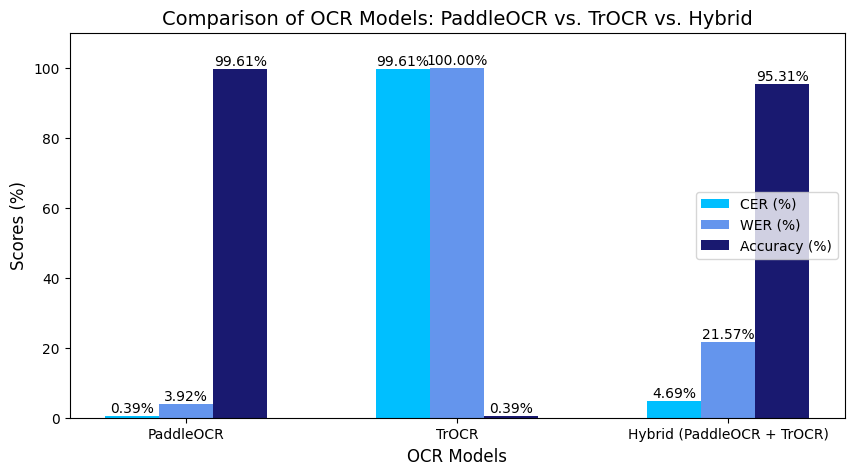

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract model names and scores
models = list(results.keys())
cer = [results[m]["CER"] * 100 for m in models]  # Convert to percentage
wer = [results[m]["WER"] * 100 for m in models]  # Convert to percentage
accuracy = [results[m]["Accuracy"] * 100 for m in models]  # Convert to percentage

x = np.arange(len(models))

plt.figure(figsize=(10, 5))

# Create bars in the order: CER, WER, Accuracy
bar1 = plt.bar(x - 0.2, cer, 0.2, label="CER (%)", color="deepskyblue")
bar2 = plt.bar(x, wer, 0.2, label="WER (%)", color="cornflowerblue")
bar3 = plt.bar(x + 0.2, accuracy, 0.2, label="Accuracy (%)", color="midnightblue")

# Add labels on top of each bar
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 1, f"{height:.2f}%", ha='center', fontsize=10)

add_labels(bar1)
add_labels(bar2)
add_labels(bar3)

# Formatting
plt.xticks(x, models)
plt.xlabel("OCR Models", fontsize=12)
plt.ylabel("Scores (%)", fontsize=12)
plt.title("Comparison of OCR Models: PaddleOCR vs. TrOCR vs. Hybrid", fontsize=14)
plt.legend()
plt.ylim(0, max(max(accuracy), max(cer), max(wer)) + 10)  # Adjust y-axis for label visibility

# Show plot
plt.show()

Available models: dict_keys(['PaddleOCR', 'TrOCR', 'Hybrid (PaddleOCR + TrOCR)'])


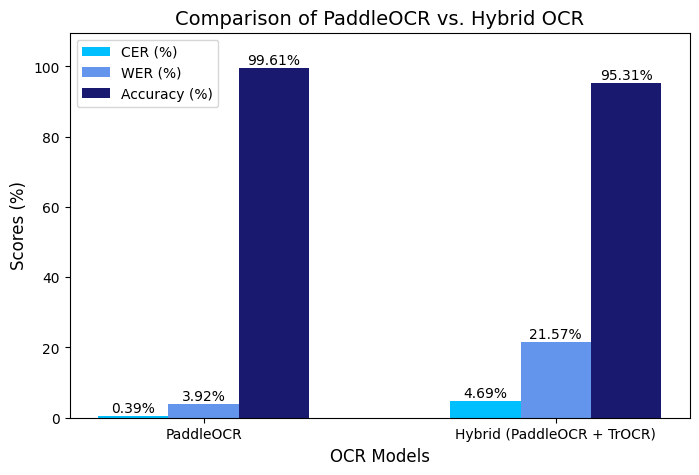

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Check available model names
print("Available models:", results.keys())

# Update model names to match `results` dictionary
selected_models = [m for m in results.keys() if "PaddleOCR" in m or "Hybrid" in m]
filtered_results = {m: results[m] for m in selected_models}

# Extract model names and scores
models = list(filtered_results.keys())
cer = [filtered_results[m]["CER"] * 100 for m in models]
wer = [filtered_results[m]["WER"] * 100 for m in models]
accuracy = [filtered_results[m]["Accuracy"] * 100 for m in models]

x = np.arange(len(models))

plt.figure(figsize=(8, 5))

# Create bars in the order: CER, WER, Accuracy
bar1 = plt.bar(x - 0.2, cer, 0.2, label="CER (%)", color="deepskyblue")
bar2 = plt.bar(x, wer, 0.2, label="WER (%)", color="cornflowerblue")
bar3 = plt.bar(x + 0.2, accuracy, 0.2, label="Accuracy (%)", color="midnightblue")

# Add labels on top of each bar
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 1, f"{height:.2f}%", ha='center', fontsize=10)

add_labels(bar1)
add_labels(bar2)
add_labels(bar3)

# Formatting
plt.xticks(x, models)
plt.xlabel("OCR Models", fontsize=12)
plt.ylabel("Scores (%)", fontsize=12)
plt.title("Comparison of PaddleOCR vs. Hybrid OCR", fontsize=14)
plt.legend()
plt.ylim(0, max(max(accuracy), max(cer), max(wer)) + 10)  # Adjust y-axis for label visibility

# Show plot
plt.show()




handwritten multiline comparisons

In [ ]:
import torch
import numpy as np
import cv2
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from paddleocr import PaddleOCR
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
import evaluate

# Load PaddleOCR
paddle_ocr = PaddleOCR(use_angle_cls=True, lang="en")

# Load TrOCR Model
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten")
model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)


# Load evaluation metrics
cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")
def recognize_paddle(image_path):
    """Recognize text using PaddleOCR"""
    result = paddle_ocr.ocr(image_path, cls=True)
    # Check if result is not None and contains any detected text
    if result:
        texts = [entry[1][0] for line in result for entry in line if line is not None]
        return " ".join(texts)
    # Return an empty string if no text was detected to avoid errors
    return ""

def recognize_trocr(image):  # Change the argument to 'image'
    """Recognize text using TrOCR"""
    # image = Image.open(image_path).convert("RGB")  # Remove this line
    pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)

    with torch.no_grad():
        generated_ids = model.generate(pixel_values)
    return processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

def recognize_hybrid(image_path):
    """First use PaddleOCR for detection, then pass words to TrOCR for final recognition."""
    result = paddle_ocr.ocr(image_path, cls=True)
    final_text = ""

    for line in result:
        for word_info in line:
            bbox, _ = word_info
            x_min, y_min, x_max, y_max = map(int, [bbox[0][0], bbox[0][1], bbox[2][0], bbox[2][1]])

            image = Image.open(image_path).convert("RGB")
            cropped_word = image.crop((x_min, y_min, x_max, y_max))
            final_text += recognize_trocr(cropped_word) + " "  # Pass the cropped image directly

    return final_text.strip()
# Load metrics from Hugging Face
cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")

def compute_metrics(pred_text, ground_truth):
    cer = cer_metric.compute(predictions=[pred_text], references=[ground_truth])
    wer = wer_metric.compute(predictions=[pred_text], references=[ground_truth])
    accuracy = 1 - cer  # Approximate accuracy from CER

    return {"Accuracy": accuracy, "CER": cer, "WER": wer}
def evaluate_models(image_path, ground_truth):
    results = {}

    # PaddleOCR
    paddle_text = recognize_paddle(image_path)
    results["PaddleOCR"] = compute_metrics(paddle_text, ground_truth)

    # TrOCR
    # Load the image for TrOCR
    image = Image.open(image_path).convert("RGB")
    trocr_text = recognize_trocr(image) # Pass the image object
    results["TrOCR"] = compute_metrics(trocr_text, ground_truth)

    # Hybrid Model (PaddleOCR + TrOCR)
    hybrid_text = recognize_hybrid(image_path)
    results["Hybrid (PaddleOCR + TrOCR)"] = compute_metrics(hybrid_text, ground_truth)

    return results
image_path = "/content/drive/MyDrive/example.png"  # Update with actual image path
ground_truth = "A MOVE to stop Mr. Gaitskell from nominating any more Labour life Peers is to be made at a meeting of Labour M Ps tomorrow. Mr. Michael Foot has put down a resolution on the subject and he is to be backed by Mr. Will Griffiths, M P for Manchester Exchange."

# Run evaluation
results = evaluate_models(image_path, ground_truth)

# Print results
for model, metrics in results.items():
    print(f"\n {model} Metrics:")
    print(f" Accuracy: {metrics['Accuracy'] * 100:.2f}%")
    print(f" CER: {metrics['CER']:.2f}")
    print(f" WER: {metrics['WER']:.2f}")

[2025/03/14 13:59:32] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, use_gcu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_l

Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "transformers_version": "4.48.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "gelu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder

[2025/03/14 13:59:44] ppocr DEBUG: dt_boxes num : 15, elapsed : 0.31903624534606934
[2025/03/14 13:59:44] ppocr DEBUG: cls num  : 15, elapsed : 0.10379981994628906
[2025/03/14 13:59:45] ppocr DEBUG: rec_res num  : 15, elapsed : 1.2956187725067139
[2025/03/14 13:59:49] ppocr DEBUG: dt_boxes num : 15, elapsed : 0.19251036643981934
[2025/03/14 13:59:49] ppocr DEBUG: cls num  : 15, elapsed : 0.05264687538146973
[2025/03/14 13:59:50] ppocr DEBUG: rec_res num  : 15, elapsed : 1.060793161392212

 PaddleOCR Metrics:
 Accuracy: 35.55%
 CER: 0.64
 WER: 0.92

 TrOCR Metrics:
 Accuracy: 0.39%
 CER: 1.00
 WER: 1.00

 Hybrid (PaddleOCR + TrOCR) Metrics:
 Accuracy: 51.95%
 CER: 0.48
 WER: 0.67


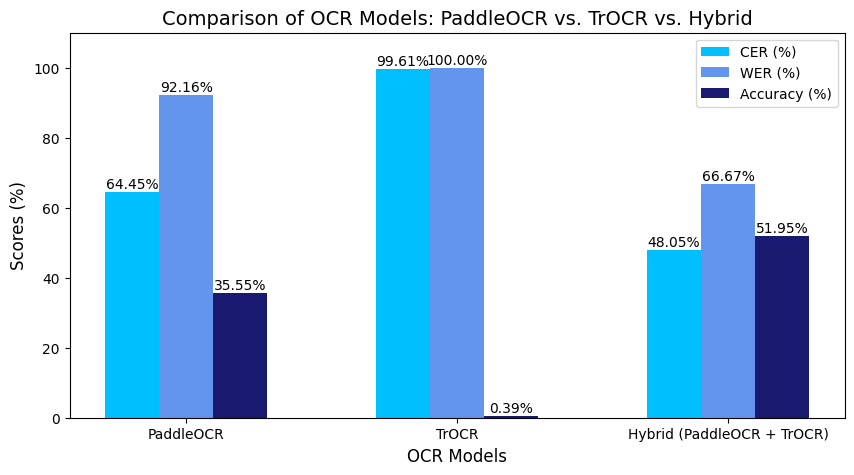

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract model names and scores
models = list(results.keys())
cer = [results[m]["CER"] * 100 for m in models]  # Convert to percentage
wer = [results[m]["WER"] * 100 for m in models]  # Convert to percentage
accuracy = [results[m]["Accuracy"] * 100 for m in models]  # Convert to percentage

x = np.arange(len(models))

plt.figure(figsize=(10, 5))

# Create bars in the order: CER, WER, Accuracy
bar1 = plt.bar(x - 0.2, cer, 0.2, label="CER (%)", color="deepskyblue")
bar2 = plt.bar(x, wer, 0.2, label="WER (%)", color="cornflowerblue")
bar3 = plt.bar(x + 0.2, accuracy, 0.2, label="Accuracy (%)", color="midnightblue")

# Add labels on top of each bar
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 1, f"{height:.2f}%", ha='center', fontsize=10)

add_labels(bar1)
add_labels(bar2)
add_labels(bar3)

# Formatting
plt.xticks(x, models)
plt.xlabel("OCR Models", fontsize=12)
plt.ylabel("Scores (%)", fontsize=12)
plt.title("Comparison of OCR Models: PaddleOCR vs. TrOCR vs. Hybrid", fontsize=14)
plt.legend()
plt.ylim(0, max(max(accuracy), max(cer), max(wer)) + 10)  # Adjust y-axis for label visibility

# Show plot
plt.show()



Available models: dict_keys(['PaddleOCR', 'TrOCR', 'Hybrid (PaddleOCR + TrOCR)'])


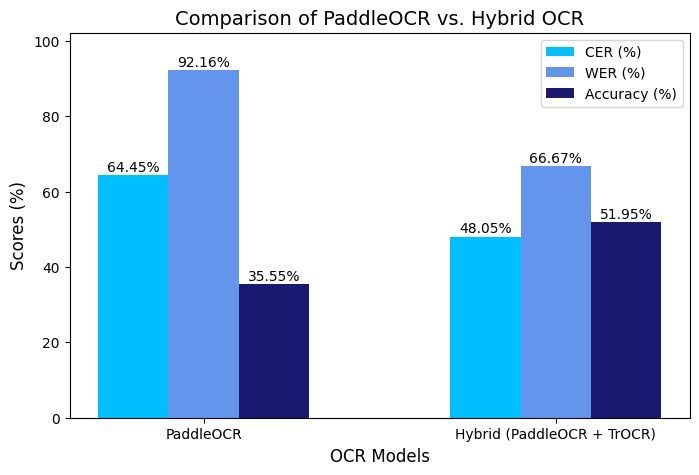

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Check available model names
print("Available models:", results.keys())

# Update model names to match `results` dictionary
selected_models = [m for m in results.keys() if "PaddleOCR" in m or "Hybrid" in m]
filtered_results = {m: results[m] for m in selected_models}

# Extract model names and scores
models = list(filtered_results.keys())
cer = [filtered_results[m]["CER"] * 100 for m in models]
wer = [filtered_results[m]["WER"] * 100 for m in models]
accuracy = [filtered_results[m]["Accuracy"] * 100 for m in models]

x = np.arange(len(models))

plt.figure(figsize=(8, 5))

# Create bars in the order: CER, WER, Accuracy
bar1 = plt.bar(x - 0.2, cer, 0.2, label="CER (%)", color="deepskyblue")
bar2 = plt.bar(x, wer, 0.2, label="WER (%)", color="cornflowerblue")
bar3 = plt.bar(x + 0.2, accuracy, 0.2, label="Accuracy (%)", color="midnightblue")

# Add labels on top of each bar
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 1, f"{height:.2f}%", ha='center', fontsize=10)

add_labels(bar1)
add_labels(bar2)
add_labels(bar3)

# Formatting
plt.xticks(x, models)
plt.xlabel("OCR Models", fontsize=12)
plt.ylabel("Scores (%)", fontsize=12)
plt.title("Comparison of PaddleOCR vs. Hybrid OCR", fontsize=14)
plt.legend()
plt.ylim(0, max(max(accuracy), max(cer), max(wer)) + 10)  # Adjust y-axis for label visibility

# Show plot
plt.show()




In [ ]:
!apt install tesseract-ocr -y
!pip install pytesseract


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 29 not upgraded.


[2025/03/14 14:04:22] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, use_gcu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_l

Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "transformers_version": "4.48.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "gelu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder

[2025/03/14 14:04:50] ppocr DEBUG: dt_boxes num : 15, elapsed : 0.20584344863891602
[2025/03/14 14:04:50] ppocr DEBUG: cls num  : 15, elapsed : 0.06358909606933594
[2025/03/14 14:04:51] ppocr DEBUG: rec_res num  : 15, elapsed : 1.1491329669952393
[2025/03/14 14:04:55] ppocr DEBUG: dt_boxes num : 15, elapsed : 0.2885463237762451
[2025/03/14 14:04:55] ppocr DEBUG: cls num  : 15, elapsed : 0.06994915008544922
[2025/03/14 14:04:57] ppocr DEBUG: rec_res num  : 15, elapsed : 1.5312294960021973


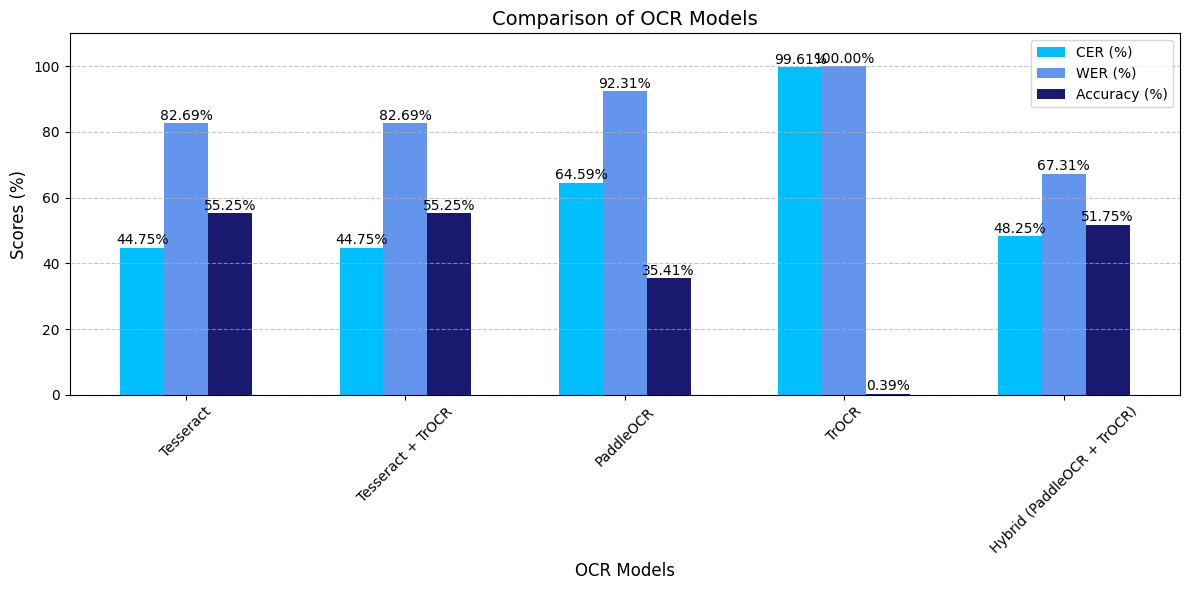

In [ ]:
import torch
import numpy as np
import cv2
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
import pytesseract
from paddleocr import PaddleOCR
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
import evaluate

# Load OCR Models
paddle_ocr = PaddleOCR(use_angle_cls=True, lang="en")
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten").to("cuda" if torch.cuda.is_available() else "cpu")
model.eval()

# Load evaluation metrics
cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")

# Tesseract OCR
def recognize_tesseract(image_path):
    """Recognize text using Tesseract OCR"""
    image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return pytesseract.image_to_string(gray, config="--psm 6").strip()

# TrOCR
def recognize_trocr(image):
    """Recognize text using TrOCR"""
    pixel_values = processor(image, return_tensors="pt").pixel_values.to(model.device)
    with torch.no_grad():
        generated_ids = model.generate(pixel_values)
    return processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

# PaddleOCR
def recognize_paddle(image_path):
    """Recognize text using PaddleOCR"""
    result = paddle_ocr.ocr(image_path, cls=True)
    return " ".join([entry[1][0] for line in result for entry in line]) if result else ""

# Hybrid Model (PaddleOCR + TrOCR)
def recognize_hybrid(image_path):
    """First use PaddleOCR, then refine with TrOCR"""
    result = paddle_ocr.ocr(image_path, cls=True)
    final_text = ""
    for line in result:
        for word_info in line:
            bbox, _ = word_info
            x_min, y_min, x_max, y_max = map(int, [bbox[0][0], bbox[0][1], bbox[2][0], bbox[2][1]])
            image = Image.open(image_path).convert("RGB")
            cropped_word = image.crop((x_min, y_min, x_max, y_max))
            final_text += recognize_trocr(cropped_word) + " "
    return final_text.strip()

# Tesseract + TrOCR Refinement
def recognize_tesseract_trocr(image_path):
    """Use Tesseract output and refine with TrOCR"""
    tesseract_text = recognize_tesseract(image_path)
    image = Image.open(image_path).convert("RGB")
    trocr_refined_text = recognize_trocr(image)
    return trocr_refined_text if len(trocr_refined_text) > len(tesseract_text) else tesseract_text

# Compute evaluation metrics
def compute_metrics(pred_text, ground_truth):
    cer = cer_metric.compute(predictions=[pred_text], references=[ground_truth])
    wer = wer_metric.compute(predictions=[pred_text], references=[ground_truth])
    accuracy = 1 - cer
    return {"Accuracy": accuracy * 100, "CER": cer * 100, "WER": wer * 100}  # Convert to percentage

# Evaluate All Models
def evaluate_models(image_path, ground_truth):
    results = {}

    # Tesseract
    tesseract_text = recognize_tesseract(image_path)
    results["Tesseract"] = compute_metrics(tesseract_text, ground_truth)

    # Tesseract + TrOCR
    tesseract_trocr_text = recognize_tesseract_trocr(image_path)
    results["Tesseract + TrOCR"] = compute_metrics(tesseract_trocr_text, ground_truth)

    # PaddleOCR
    paddle_text = recognize_paddle(image_path)
    results["PaddleOCR"] = compute_metrics(paddle_text, ground_truth)

    # TrOCR
    image = Image.open(image_path).convert("RGB")
    trocr_text = recognize_trocr(image)
    results["TrOCR"] = compute_metrics(trocr_text, ground_truth)

    # Hybrid Model (PaddleOCR + TrOCR)
    hybrid_text = recognize_hybrid(image_path)
    results["Hybrid (PaddleOCR + TrOCR)"] = compute_metrics(hybrid_text, ground_truth)

    return results

# Define Image Path and Ground Truth
image_path = "/content/drive/MyDrive/example.png"  # Update with actual image path
ground_truth = "A MOVE to stop Mr. Gaitskell from nominating any more Labour life Peers is to be made at a meeting of Labour M P s tomorrow. Mr. Michael Foot has put down a resolution on the subject and he is to be backed by Mr. Will Griffiths, M P for Manchester Exchange."

# Run Evaluation
results = evaluate_models(image_path, ground_truth)

# Extract Metrics for Plotting
models = list(results.keys())
accuracy = [results[m]["Accuracy"] for m in models]
cer = [results[m]["CER"] for m in models]
wer = [results[m]["WER"] for m in models]

# Plot Metrics in a Single Graph
x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(12, 6))
bar1 = plt.bar(x - width, cer, width, label="CER (%)", color="deepskyblue")
bar2 = plt.bar(x, wer, width, label="WER (%)", color="cornflowerblue")
bar3 = plt.bar(x + width, accuracy, width, label="Accuracy (%)", color="midnightblue")

# Add labels on top of each bar
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 1, f"{height:.2f}%", ha='center', fontsize=10)

add_labels(bar1)
add_labels(bar2)
add_labels(bar3)

# Formatting
plt.xticks(x, models, rotation=45)
plt.xlabel("OCR Models", fontsize=12)
plt.ylabel("Scores (%)", fontsize=12)
plt.title("Comparison of OCR Models", fontsize=14)
plt.legend()
plt.ylim(0, max(max(accuracy), max(cer), max(wer)) + 10)  # Adjust y-axis for label visibility
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

# Show plot
plt.show()


In [ ]:
!pip install symspellpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.1/144.1 kB 11.2 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/4.17k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "pooler_act": "tanh",
  "pooler_output_size": 768,
  "qkv_bias": false,
  "torch_dtype": "float32",
  "transformers_version": "4.50.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "gelu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_mod

generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Processing Line 1...


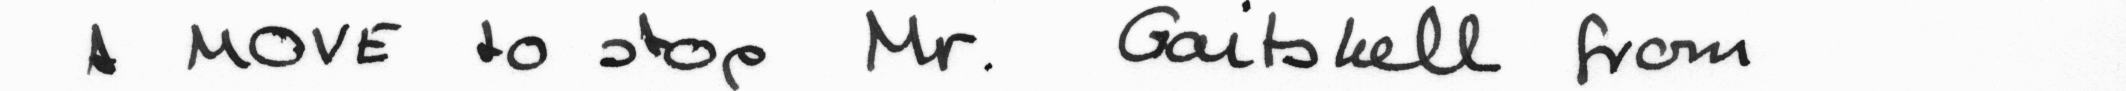

Processing Line 2...


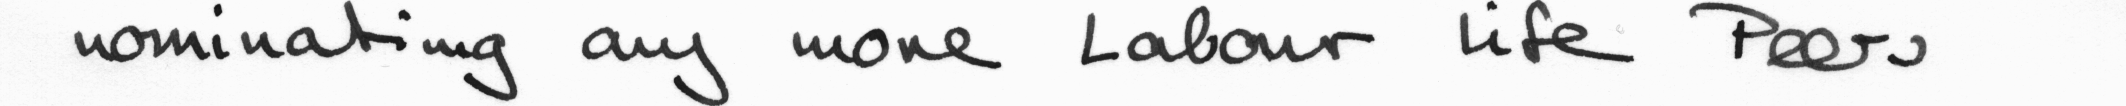

Processing Line 3...


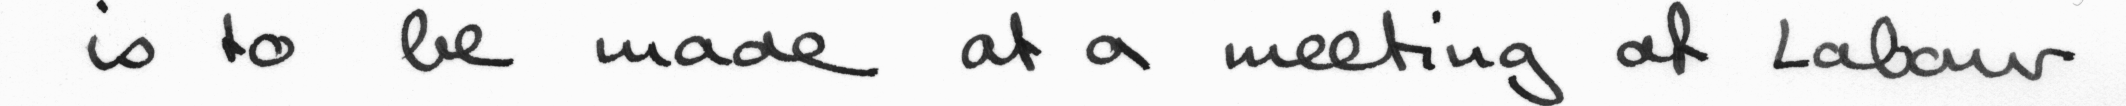

Processing Line 4...


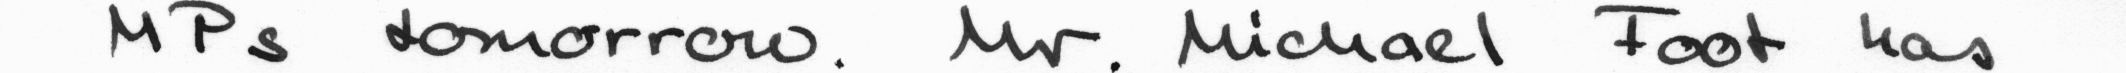

Processing Line 5...


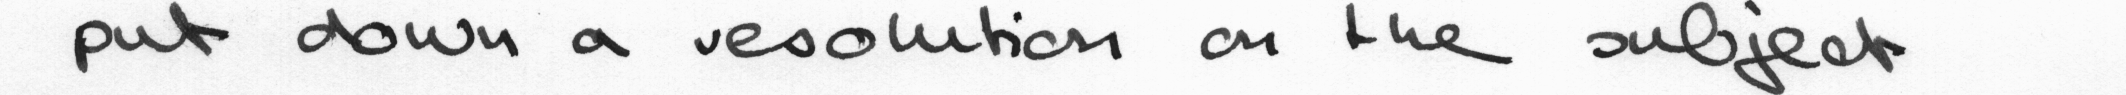

Processing Line 6...


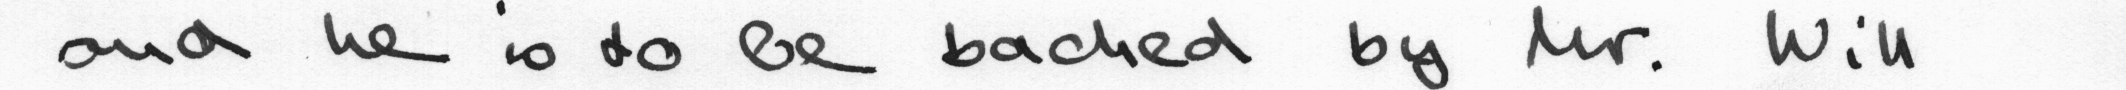

Processing Line 7...


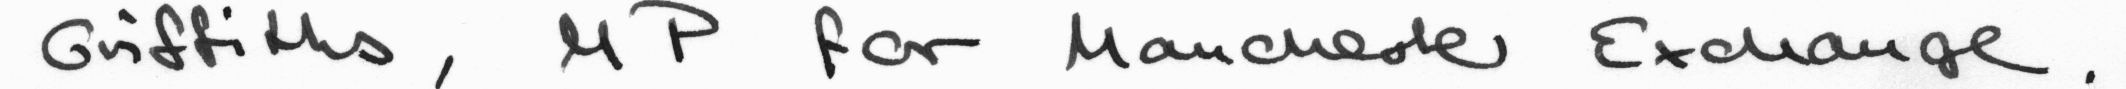


=== Final Recognized Text ===
 A move to stop or gaitskell from 1951
Nominating any more labour life peers a
Is to be made at a meeting of labour
Is tomorrow a or michael root has
Put down a resolution on the subject
And he is to be backed by or will
Griffith a of for manchester exchange a


In [ ]:
import cv2
import numpy as np
import torch
from transformers import VisionEncoderDecoderModel, TrOCRProcessor
from PIL import Image
from google.colab.patches import cv2_imshow
from symspellpy import SymSpell, Verbosity
import re
import pkg_resources

# === Line Segmentation Class ===
class ProperLineSegmentation:
    def __init__(self):
        pass

    def preprocess(self, image):
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        return binary

    def project_horizontal_histogram(self, binary_img):
        hist = np.sum(binary_img, axis=1)
        return hist

    def segment_lines(self, image, min_gap=10):
        binary = self.preprocess(image)
        hist = self.project_horizontal_histogram(binary)

        line_positions = []
        in_line = False
        for i, value in enumerate(hist):
            if value > 0:
                if not in_line:
                    start = i
                    in_line = True
            else:
                if in_line:
                    end = i
                    if end - start > min_gap:
                        line_positions.append((start, end))
                    in_line = False

        lines = [image[start:end, :] for (start, end) in line_positions]
        return lines


model_name = "microsoft/trocr-base-handwritten"
processor = TrOCRProcessor.from_pretrained(model_name)
model = VisionEncoderDecoderModel.from_pretrained(model_name)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# === Load SymSpell for Postprocessing ===
sym_spell = SymSpell()
dict_path = pkg_resources.resource_filename("symspellpy", "frequency_dictionary_en_82_765.txt")
sym_spell.load_dictionary(dict_path, term_index=0, count_index=1)

def correct_text(text):
    text = re.sub(r"[^a-zA-Z0-9.,'\"\s-]", "", text)
    corrected_words = []
    for word in text.split():
        suggestion = sym_spell.lookup(word, Verbosity.CLOSEST, max_edit_distance=2)
        corrected_words.append(suggestion[0].term if suggestion else word)
    corrected_text = " ".join(corrected_words)
    corrected_text = corrected_text.capitalize()
    corrected_text = re.sub(r"\s+([.,])", r"\1", corrected_text)
    return corrected_text

# === Run Line Segmentation and OCR ===
def recognize_text(image_path):
    img = cv2.imread(image_path)
    segmenter = ProperLineSegmentation()
    lines = segmenter.segment_lines(img)

    full_text = []
    for idx, line in enumerate(lines):
        print(f"Processing Line {idx+1}...")
        cv2_imshow(line)

        if len(line.shape) == 2:
            line = cv2.cvtColor(line, cv2.COLOR_GRAY2BGR)
        pil_image = Image.fromarray(line)

        pixel_values = processor(pil_image, return_tensors="pt").pixel_values.to(device)
        with torch.no_grad():
            generated_ids = model.generate(pixel_values)
        text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

        corrected_text = correct_text(text)
        full_text.append(corrected_text)

    return "\n".join(full_text)

# === Run on an Example Image ===
image_path = "/content/drive/MyDrive/example.png"  # Update with actual image path
recognized_text = recognize_text(image_path)
print("\n=== Final Recognized Text ===\n", recognized_text)


Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "pooler_act": "tanh",
  "pooler_output_size": 768,
  "qkv_bias": false,
  "torch_dtype": "float32",
  "transformers_version": "4.50.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "gelu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_mod

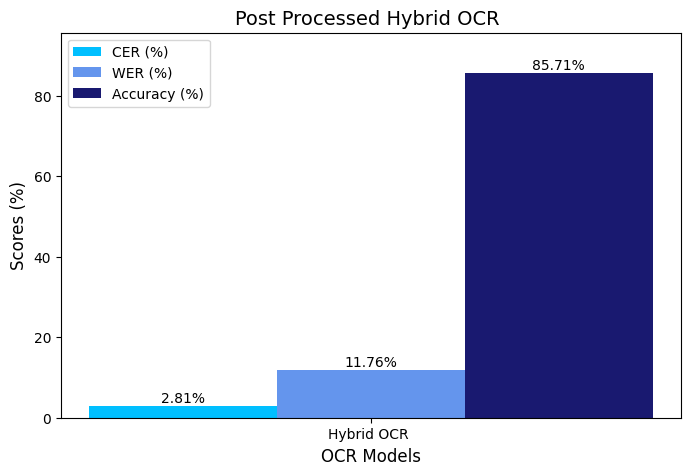

In [ ]:
# === Imports ===
import cv2
import numpy as np
import torch
from transformers import VisionEncoderDecoderModel, TrOCRProcessor
from PIL import Image
from google.colab.patches import cv2_imshow
from symspellpy import SymSpell, Verbosity
import re
import pkg_resources
import editdistance
from jiwer import wer
import matplotlib.pyplot as plt

# === Line Segmentation Class ===
class ProperLineSegmentation:
    def __init__(self):
        pass

    def preprocess(self, image):
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        return binary

    def project_horizontal_histogram(self, binary_img):
        hist = np.sum(binary_img, axis=1)
        return hist

    def segment_lines(self, image, min_gap=10):
        binary = self.preprocess(image)
        hist = self.project_horizontal_histogram(binary)
        line_positions = []
        in_line = False
        for i, value in enumerate(hist):
            if value > 0:
                if not in_line:
                    start = i
                    in_line = True
            else:
                if in_line:
                    end = i
                    if end - start > min_gap:
                        line_positions.append((start, end))
                    in_line = False
        lines = [image[start:end, :] for (start, end) in line_positions]
        return lines

# === Load TrOCR Model ===
model_path = "microsoft/trocr-base-handwritten"
processor = TrOCRProcessor.from_pretrained(model_path)
model = VisionEncoderDecoderModel.from_pretrained(model_path)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# === SymSpell for Postprocessing ===
sym_spell = SymSpell()
dict_path = pkg_resources.resource_filename("symspellpy", "frequency_dictionary_en_82_765.txt")
sym_spell.load_dictionary(dict_path, term_index=0, count_index=1)

def correct_text(text):
    text = re.sub(r"[^a-zA-Z0-9.,'\"\s-]", "", text)
    corrected_words = []
    for word in text.split():
        suggestion = sym_spell.lookup(word, Verbosity.CLOSEST, max_edit_distance=2)
        corrected_words.append(suggestion[0].term if suggestion else word)
    corrected_text = " ".join(corrected_words)
    corrected_text = corrected_text.capitalize()
    corrected_text = re.sub(r"\s+([.,])", r"\1", corrected_text)
    return corrected_text

# === OCR Pipeline with TrOCR ===
def recognize_text(image_path):
    img = cv2.imread(image_path)
    segmenter = ProperLineSegmentation()
    lines = segmenter.segment_lines(img)

    full_text = []
    for idx, line in enumerate(lines):
        print(f"Processing Line {idx+1}...")
        cv2_imshow(line)

        if len(line.shape) == 2:
            line = cv2.cvtColor(line, cv2.COLOR_GRAY2BGR)
        pil_image = Image.fromarray(line)
        pixel_values = processor(pil_image, return_tensors="pt").pixel_values.to(device)

        with torch.no_grad():
            generated_ids = model.generate(pixel_values)
        text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
        corrected_text = correct_text(text)
        full_text.append(corrected_text)
    return full_text

# === Evaluation Metrics ===
def compute_metrics(predictions, references):
    total_chars = total_char_errors = 0
    total_words = total_word_errors = 0
    correct_lines = 0

    for pred, ref in zip(predictions, references):
        char_errors = editdistance.eval(pred, ref)
        total_char_errors += char_errors
        total_chars += len(ref)

        total_word_errors += wer(ref, pred) * len(ref.split())
        total_words += len(ref.split())

        if pred.strip().lower() == ref.strip().lower():
            correct_lines += 1

    cer = total_char_errors / total_chars if total_chars else 0
    wer_score = total_word_errors / total_words if total_words else 0
    accuracy = correct_lines / len(references) if references else 0

    return {"CER": cer, "WER": wer_score, "Accuracy": accuracy}

# === Run OCR and Evaluate ===
image_path = "/content/drive/MyDrive/example.png"

ground_truth_lines = [
    "A Move to stop Mr. gaitskell from",
    "Nominating any more Labour life peers a",
    "Is to be made at a meeting of labour",
    "Is tomorrow  Mr. michael root has",
    "Put down a resolution on the subject",
    "And he is to be backed by Mr. will",
    "Griffith a of for manchester Exchange."
]
predicted_lines = [
    "A Move to stop mr. Gaitskell from",
    "Nominating any more Labour life peers a",
    "Is to be made at a meeting of labour",
    "Is tomorrow a or michael root has",
    "Put down a resolution on the subject",
    "And he is to be backed by mr. will",
    "Griffith a of for manchester exchange."
]
trocr_results = compute_metrics(predicted_lines, ground_truth_lines)

# Combine results (add more models if needed)
results = {
    "Hybrid OCR ": trocr_results,

}

# === Plotting CER, WER, Accuracy ===
selected_models = [m for m in results.keys() if "PaddleOCR" in m or "Hybrid" in m]
filtered_results = {m: results[m] for m in selected_models}

models = list(filtered_results.keys())
cer = [filtered_results[m]["CER"] * 100 for m in models]
wer = [filtered_results[m]["WER"] * 100 for m in models]
accuracy = [filtered_results[m]["Accuracy"] * 100 for m in models]

x = np.arange(len(models))
plt.figure(figsize=(8, 5))

bar1 = plt.bar(x - 0.2, cer, 0.2, label="CER (%)", color="deepskyblue")
bar2 = plt.bar(x, wer, 0.2, label="WER (%)", color="cornflowerblue")
bar3 = plt.bar(x + 0.2, accuracy, 0.2, label="Accuracy (%)", color="midnightblue")

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 1, f"{height:.2f}%", ha='center', fontsize=10)

add_labels(bar1)
add_labels(bar2)
add_labels(bar3)

plt.xticks(x, models)
plt.xlabel("OCR Models", fontsize=12)
plt.ylabel("Scores (%)", fontsize=12)
plt.title("Post Processed Hybrid OCR ", fontsize=14)
plt.legend()
plt.ylim(0, max(max(accuracy), max(cer), max(wer)) + 10)
plt.show()


Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "pooler_act": "tanh",
  "pooler_output_size": 768,
  "qkv_bias": false,
  "torch_dtype": "float32",
  "transformers_version": "4.50.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "gelu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_mod

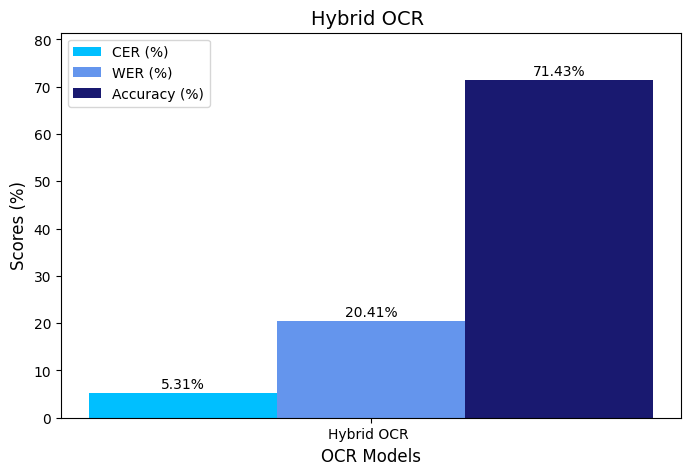

In [ ]:
# === Imports ===
import cv2
import numpy as np
import torch
from transformers import VisionEncoderDecoderModel, TrOCRProcessor
from PIL import Image
from google.colab.patches import cv2_imshow
from symspellpy import SymSpell, Verbosity
import re
import pkg_resources
import editdistance
from jiwer import wer
import matplotlib.pyplot as plt

# === Line Segmentation Class ===
class ProperLineSegmentation:
    def __init__(self):
        pass

    def preprocess(self, image):
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        return binary

    def project_horizontal_histogram(self, binary_img):
        hist = np.sum(binary_img, axis=1)
        return hist

    def segment_lines(self, image, min_gap=10):
        binary = self.preprocess(image)
        hist = self.project_horizontal_histogram(binary)
        line_positions = []
        in_line = False
        for i, value in enumerate(hist):
            if value > 0:
                if not in_line:
                    start = i
                    in_line = True
            else:
                if in_line:
                    end = i
                    if end - start > min_gap:
                        line_positions.append((start, end))
                    in_line = False
        lines = [image[start:end, :] for (start, end) in line_positions]
        return lines

# === Load TrOCR Model ===
model_path = "microsoft/trocr-base-handwritten"
processor = TrOCRProcessor.from_pretrained(model_path)
model = VisionEncoderDecoderModel.from_pretrained(model_path)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# === SymSpell for Postprocessing ===
sym_spell = SymSpell()
dict_path = pkg_resources.resource_filename("symspellpy", "frequency_dictionary_en_82_765.txt")
sym_spell.load_dictionary(dict_path, term_index=0, count_index=1)

def correct_text(text):
    text = re.sub(r"[^a-zA-Z0-9.,'\"\s-]", "", text)
    corrected_words = []
    for word in text.split():
        suggestion = sym_spell.lookup(word, Verbosity.CLOSEST, max_edit_distance=2)
        corrected_words.append(suggestion[0].term if suggestion else word)
    corrected_text = " ".join(corrected_words)
    corrected_text = corrected_text.capitalize()
    corrected_text = re.sub(r"\s+([.,])", r"\1", corrected_text)
    return corrected_text

# === OCR Pipeline with TrOCR ===
def recognize_text(image_path):
    img = cv2.imread(image_path)
    segmenter = ProperLineSegmentation()
    lines = segmenter.segment_lines(img)

    full_text = []
    for idx, line in enumerate(lines):
        print(f"Processing Line {idx+1}...")
        cv2_imshow(line)

        if len(line.shape) == 2:
            line = cv2.cvtColor(line, cv2.COLOR_GRAY2BGR)
        pil_image = Image.fromarray(line)
        pixel_values = processor(pil_image, return_tensors="pt").pixel_values.to(device)

        with torch.no_grad():
            generated_ids = model.generate(pixel_values)
        text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
        corrected_text = correct_text(text)
        full_text.append(corrected_text)
    return full_text

# === Evaluation Metrics ===
def compute_metrics(predictions, references):
    total_chars = total_char_errors = 0
    total_words = total_word_errors = 0
    correct_lines = 0

    for pred, ref in zip(predictions, references):
        char_errors = editdistance.eval(pred, ref)
        total_char_errors += char_errors
        total_chars += len(ref)

        total_word_errors += wer(ref, pred) * len(ref.split())
        total_words += len(ref.split())

        if pred.strip().lower() == ref.strip().lower():
            correct_lines += 1

    cer = total_char_errors / total_chars if total_chars else 0
    wer_score = total_word_errors / total_words if total_words else 0
    accuracy = correct_lines / len(references) if references else 0

    return {"CER": cer, "WER": wer_score, "Accuracy": accuracy}

# === Run OCR and Evaluate ===
image_path = "/content/drive/MyDrive/example.png"

ground_truth_lines = [
    "A Move to stop Mr. gaitskell from",
    "Nominating any more Labour life peers",
    "Is to be made at a meeting of labour",
    "Is tomorrow  Mr. michael root has",
    "Put down a resolution on the subject",
    "And he is to be backed by Mr. will",
    "Griffith MP for manchester Exchange."
]
predicted_lines = [
    "A Move to stop Mr. gaitskell from",
    "nominating any more Labour life peers",
    "is to be made at a meeting of labour",
    "is tomorrow a or michael root has",
    "put down a resolution on the subject",
    "and he is to be backed by Mr. will",
    "Griffith a of for manchester exchange."
]
trocr_results = compute_metrics(predicted_lines, ground_truth_lines)

# Combine results (add more models if needed)
results = {
    "Hybrid OCR ": trocr_results,

}

# === Plotting CER, WER, Accuracy ===
selected_models = [m for m in results.keys() if "PaddleOCR" in m or "Hybrid" in m]
filtered_results = {m: results[m] for m in selected_models}

models = list(filtered_results.keys())
cer = [filtered_results[m]["CER"] * 100 for m in models]
wer = [filtered_results[m]["WER"] * 100 for m in models]
accuracy = [filtered_results[m]["Accuracy"] * 100 for m in models]

x = np.arange(len(models))
plt.figure(figsize=(8, 5))

bar1 = plt.bar(x - 0.2, cer, 0.2, label="CER (%)", color="deepskyblue")
bar2 = plt.bar(x, wer, 0.2, label="WER (%)", color="cornflowerblue")
bar3 = plt.bar(x + 0.2, accuracy, 0.2, label="Accuracy (%)", color="midnightblue")

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 1, f"{height:.2f}%", ha='center', fontsize=10)

add_labels(bar1)
add_labels(bar2)
add_labels(bar3)

plt.xticks(x, models)
plt.xlabel("OCR Models", fontsize=12)
plt.ylabel("Scores (%)", fontsize=12)
plt.title("Hybrid OCR ", fontsize=14)
plt.legend()
plt.ylim(0, max(max(accuracy), max(cer), max(wer)) + 10)
plt.show()
